<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# DETR: detecção de objetos com Transformers

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

Este notebook apresenta, de forma reproduzível, os mecanismos centrais do DETR: **predição em conjunto**, **codificação posicional 2D**, **object queries**, **matching bipartido** e a função de perda de localização. A implementação usa NumPy, SciPy e Matplotlib para tornar cada etapa observável.

## Como interpretar o experimento

O objetivo não é treinar uma rede completa. Em vez disso, construiremos uma cena controlada, simularemos as saídas de oito *object queries* e aplicaremos o mesmo princípio de associação um-para-um usado no treinamento do DETR. Isso permite observar por que predições duplicadas não recebem o mesmo objeto como alvo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
from scipy.optimize import linear_sum_assignment

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

CORES = {
    "vermelho": "#E45756",
    "azul": "#4C78A8",
    "verde": "#54A24B",
    "sem objeto": "#9CA3AF",
}

## 1. Cena sintética e caixas normalizadas

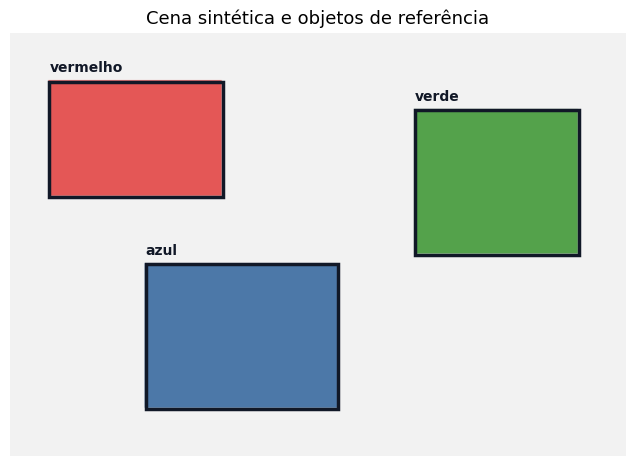

Caixas de referência no formato (centro_x, centro_y, largura, altura):
[[0.203 0.25  0.281 0.273]
 [0.375 0.716 0.312 0.341]
 [0.789 0.352 0.266 0.341]]


In [2]:
altura, largura = 220, 320
imagem = np.full((altura, largura, 3), 242, dtype=np.uint8)

# Objetos definidos como (x_min, y_min, x_max, y_max), em pixels.
objetos = [
    ("vermelho", (20, 25, 110, 85)),
    ("azul", (70, 120, 170, 195)),
    ("verde", (210, 40, 295, 115)),
]

for nome, (x1, y1, x2, y2) in objetos:
    cor_rgb = {
        "vermelho": (228, 87, 86),
        "azul": (76, 120, 168),
        "verde": (84, 162, 75),
    }[nome]
    imagem[y1:y2, x1:x2] = cor_rgb

def xyxy_para_cxcywh_normalizada(caixa, largura_img, altura_img):
    x1, y1, x2, y2 = caixa
    return np.array([
        ((x1 + x2) / 2) / largura_img,
        ((y1 + y2) / 2) / altura_img,
        (x2 - x1) / largura_img,
        (y2 - y1) / altura_img,
    ], dtype=np.float64)

classes_gt = np.array([0, 1, 2])
caixas_gt = np.vstack([
    xyxy_para_cxcywh_normalizada(caixa, largura, altura)
    for _, caixa in objetos
])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(imagem)
for nome, (x1, y1, x2, y2) in objetos:
    ax.add_patch(Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        fill=False, linewidth=2.5, edgecolor="#111827"
    ))
    ax.text(x1, y1 - 5, nome, color="#111827", weight="bold")
ax.set_title("Cena sintética e objetos de referência")
ax.axis("off")
plt.show()

print("Caixas de referência no formato (centro_x, centro_y, largura, altura):")
print(caixas_gt)

## 2. Codificação posicional senoidal em duas dimensões

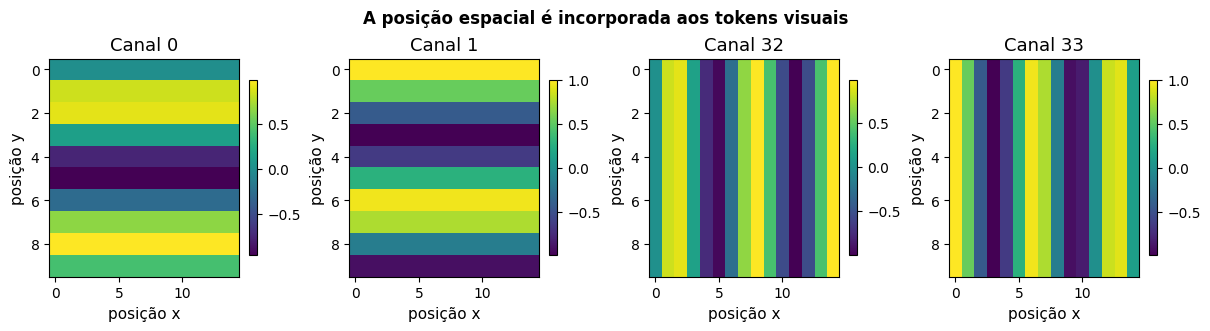

Mapa posicional: (10, 15, 64)
Sequência entregue ao Transformer: (150, 64)


In [3]:
def codificacao_posicional_2d(altura_mapa, largura_mapa, d_model):
    """Cria codificação senoidal separada para os eixos vertical e horizontal."""
    if d_model % 4 != 0:
        raise ValueError("d_model deve ser divisível por 4")

    metade = d_model // 2
    codificacao = np.zeros((altura_mapa, largura_mapa, d_model), dtype=np.float64)
    frequencias = np.exp(
        np.arange(0, metade, 2) * (-np.log(10000.0) / metade)
    )

    pos_y = np.arange(altura_mapa)[:, None, None]
    pos_x = np.arange(largura_mapa)[None, :, None]

    codificacao[:, :, 0:metade:2] = np.sin(pos_y * frequencias)
    codificacao[:, :, 1:metade:2] = np.cos(pos_y * frequencias)
    codificacao[:, :, metade::2] = np.sin(pos_x * frequencias)
    codificacao[:, :, metade + 1::2] = np.cos(pos_x * frequencias)
    return codificacao

posicional = codificacao_posicional_2d(10, 15, 64)

fig, eixos = plt.subplots(1, 4, figsize=(12, 3.2), constrained_layout=True)
for eixo, canal in zip(eixos, [0, 1, 32, 33]):
    mapa = eixo.imshow(posicional[:, :, canal], cmap="viridis", aspect="auto")
    eixo.set_title(f"Canal {canal}")
    eixo.set_xlabel("posição x")
    eixo.set_ylabel("posição y")
    fig.colorbar(mapa, ax=eixo, fraction=0.046)
fig.suptitle("A posição espacial é incorporada aos tokens visuais", weight="bold")
plt.show()

print(f"Mapa posicional: {posicional.shape}")
print(f"Sequência entregue ao Transformer: {(10 * 15, 64)}")

## 3. Fluxo arquitetural do DETR

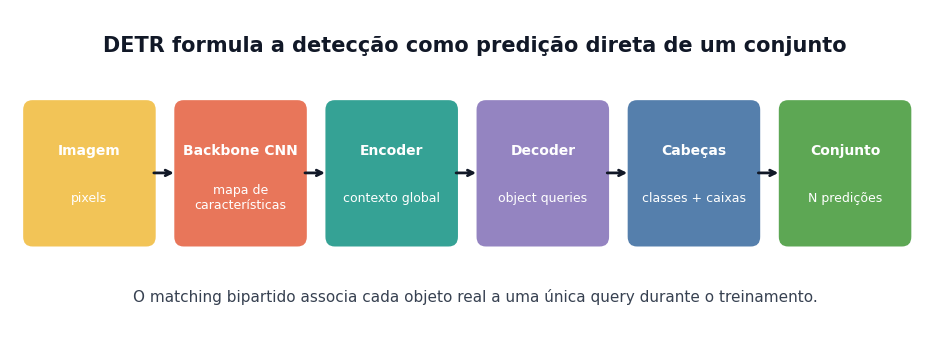

In [4]:
etapas = [
    ("Imagem", "pixels"),
    ("Backbone CNN", "mapa de\ncaracterísticas"),
    ("Encoder", "contexto global"),
    ("Decoder", "object queries"),
    ("Cabeças", "classes + caixas"),
    ("Conjunto", "N predições"),
]
cores_etapas = ["#F2C14E", "#E76F51", "#2A9D8F", "#8E7DBE", "#4C78A8", "#54A24B"]

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

for i, ((titulo, subtitulo), cor) in enumerate(zip(etapas, cores_etapas)):
    x = 0.25 + i * 1.95
    caixa = FancyBboxPatch(
        (x, 1.15), 1.55, 1.65,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=cor, edgecolor="none", alpha=0.95
    )
    ax.add_patch(caixa)
    ax.text(x + 0.775, 2.25, titulo, ha="center", va="center", weight="bold", color="white")
    ax.text(x + 0.775, 1.67, subtitulo, ha="center", va="center", fontsize=9, color="white", wrap=True)
    if i < len(etapas) - 1:
        ax.annotate(
            "", xy=(x + 1.9, 1.98), xytext=(x + 1.57, 1.98),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="#111827")
        )

ax.text(
    6, 3.55,
    "DETR formula a detecção como predição direta de um conjunto",
    ha="center", va="center", fontsize=15, weight="bold", color="#111827"
)
ax.text(
    6, 0.45,
    "O matching bipartido associa cada objeto real a uma única query durante o treinamento.",
    ha="center", va="center", fontsize=11, color="#374151"
)
plt.show()

## 4. Saídas simuladas das object queries

In [5]:
nomes_classes = np.array(["vermelho", "azul", "verde", "sem objeto"])

# Cada linha representa uma object query.
# As três primeiras posições são probabilidades de classe; a última é "sem objeto".
probabilidades = np.array([
    [0.94, 0.02, 0.02, 0.02],
    [0.83, 0.04, 0.03, 0.10],
    [0.02, 0.94, 0.02, 0.02],
    [0.06, 0.72, 0.04, 0.18],
    [0.01, 0.02, 0.95, 0.02],
    [0.12, 0.10, 0.15, 0.63],
    [0.08, 0.05, 0.07, 0.80],
    [0.10, 0.08, 0.09, 0.73],
], dtype=np.float64)

caixas_preditas = np.array([
    [0.205, 0.260, 0.290, 0.280],
    [0.230, 0.270, 0.320, 0.300],
    [0.380, 0.720, 0.310, 0.340],
    [0.400, 0.690, 0.370, 0.320],
    [0.790, 0.350, 0.270, 0.340],
    [0.520, 0.400, 0.150, 0.200],
    [0.600, 0.800, 0.200, 0.150],
    [0.100, 0.800, 0.150, 0.150],
], dtype=np.float64)

for i, (probs, caixa) in enumerate(zip(probabilidades, caixas_preditas)):
    classe = nomes_classes[np.argmax(probs)]
    print(f"query {i}: classe={classe:11s} confiança={probs.max():.2f} caixa={caixa}")

query 0: classe=vermelho    confiança=0.94 caixa=[0.205 0.26  0.29  0.28 ]
query 1: classe=vermelho    confiança=0.83 caixa=[0.23 0.27 0.32 0.3 ]
query 2: classe=azul        confiança=0.94 caixa=[0.38 0.72 0.31 0.34]
query 3: classe=azul        confiança=0.72 caixa=[0.4  0.69 0.37 0.32]
query 4: classe=verde       confiança=0.95 caixa=[0.79 0.35 0.27 0.34]
query 5: classe=sem objeto  confiança=0.63 caixa=[0.52 0.4  0.15 0.2 ]
query 6: classe=sem objeto  confiança=0.80 caixa=[0.6  0.8  0.2  0.15]
query 7: classe=sem objeto  confiança=0.73 caixa=[0.1  0.8  0.15 0.15]


## 5. Matching bipartido com o algoritmo húngaro

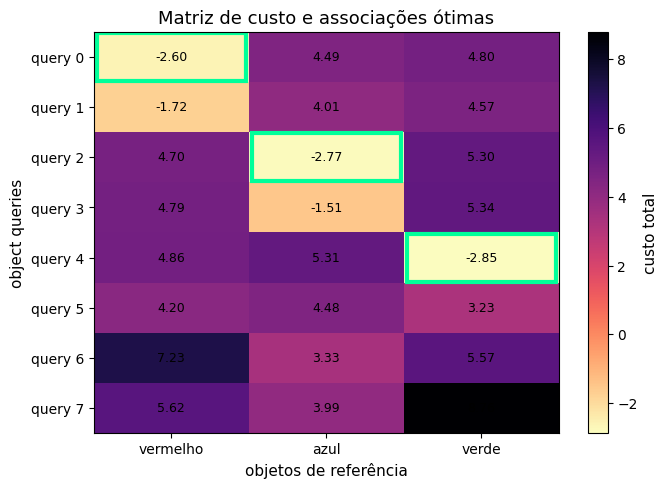

Associações selecionadas:
query 0 → objeto vermelho | custo=-2.605
query 2 → objeto azul | custo=-2.768
query 4 → objeto verde | custo=-2.849


In [6]:
def cxcywh_para_xyxy(caixas):
    cx, cy, w, h = np.moveaxis(np.asarray(caixas), -1, 0)
    return np.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], axis=-1)

def area_xyxy(caixas):
    largura_caixa = np.clip(caixas[..., 2] - caixas[..., 0], 0, None)
    altura_caixa = np.clip(caixas[..., 3] - caixas[..., 1], 0, None)
    return largura_caixa * altura_caixa

def giou_pareado(caixas_a, caixas_b):
    """Calcula GIoU entre todos os pares de dois conjuntos de caixas."""
    a = cxcywh_para_xyxy(caixas_a)[:, None, :]
    b = cxcywh_para_xyxy(caixas_b)[None, :, :]

    inter_min = np.maximum(a[..., :2], b[..., :2])
    inter_max = np.minimum(a[..., 2:], b[..., 2:])
    inter_wh = np.clip(inter_max - inter_min, 0, None)
    inter = inter_wh[..., 0] * inter_wh[..., 1]

    area_a = area_xyxy(a)
    area_b = area_xyxy(b)
    uniao = area_a + area_b - inter
    iou = inter / np.clip(uniao, 1e-9, None)

    fecho_min = np.minimum(a[..., :2], b[..., :2])
    fecho_max = np.maximum(a[..., 2:], b[..., 2:])
    fecho_wh = np.clip(fecho_max - fecho_min, 0, None)
    area_fecho = fecho_wh[..., 0] * fecho_wh[..., 1]
    giou = iou - (area_fecho - uniao) / np.clip(area_fecho, 1e-9, None)
    return giou

lambda_l1 = 5.0
lambda_giou = 2.0

custo_classe = -probabilidades[:, classes_gt]
custo_l1 = np.abs(caixas_preditas[:, None, :] - caixas_gt[None, :, :]).sum(axis=-1)
custo_giou = -giou_pareado(caixas_preditas, caixas_gt)
matriz_custo = custo_classe + lambda_l1 * custo_l1 + lambda_giou * custo_giou

queries_associadas, objetos_associados = linear_sum_assignment(matriz_custo)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
mapa = ax.imshow(matriz_custo, cmap="magma_r", aspect="auto")
for i in range(matriz_custo.shape[0]):
    for j in range(matriz_custo.shape[1]):
        ax.text(j, i, f"{matriz_custo[i, j]:.2f}", ha="center", va="center", fontsize=9)
for query, objeto in zip(queries_associadas, objetos_associados):
    ax.add_patch(Rectangle((objeto - 0.48, query - 0.48), 0.96, 0.96, fill=False, edgecolor="#00FF99", linewidth=3))
ax.set_xticks(range(len(objetos)), [nome for nome, _ in objetos])
ax.set_yticks(range(len(caixas_preditas)), [f"query {i}" for i in range(len(caixas_preditas))])
ax.set_xlabel("objetos de referência")
ax.set_ylabel("object queries")
ax.set_title("Matriz de custo e associações ótimas")
fig.colorbar(mapa, ax=ax, label="custo total")
plt.show()

print("Associações selecionadas:")
for query, objeto in zip(queries_associadas, objetos_associados):
    print(f"query {query} → objeto {objetos[objeto][0]} | custo={matriz_custo[query, objeto]:.3f}")

## 6. Componentes da função de perda

In [7]:
indice_sem_objeto = 3
alvos_classes = np.full(len(caixas_preditas), indice_sem_objeto, dtype=int)
alvos_classes[queries_associadas] = classes_gt[objetos_associados]

# A classe "sem objeto" recebe peso menor, como no treinamento do DETR.
pesos_classes = np.ones(len(caixas_preditas), dtype=np.float64)
pesos_classes[alvos_classes == indice_sem_objeto] = 0.1
perdas_ce = -np.log(np.clip(probabilidades[np.arange(len(probabilidades)), alvos_classes], 1e-9, 1.0))
loss_ce = np.average(perdas_ce, weights=pesos_classes)

pred_associadas = caixas_preditas[queries_associadas]
gt_associadas = caixas_gt[objetos_associados]
loss_l1 = np.abs(pred_associadas - gt_associadas).sum(axis=-1).mean()
giou_diagonal = np.diag(giou_pareado(pred_associadas, gt_associadas))
loss_giou = (1.0 - giou_diagonal).mean()
loss_total = loss_ce + lambda_l1 * loss_l1 + lambda_giou * loss_giou

print(f"Loss de classificação: {loss_ce:.4f}")
print(f"Loss L1:              {loss_l1:.4f}")
print(f"Loss GIoU:            {loss_giou:.4f}")
print(f"Loss total:           {loss_total:.4f}")
print(f"Queries associadas:   {len(queries_associadas)}")
print(f"Queries sem objeto:   {(alvos_classes == indice_sem_objeto).sum()}")

Loss de classificação: 0.1934
Loss L1:              0.0163
Loss GIoU:            0.0606
Loss total:           0.3961
Queries associadas:   3
Queries sem objeto:   5


## 7. Resultado da associação um-para-um

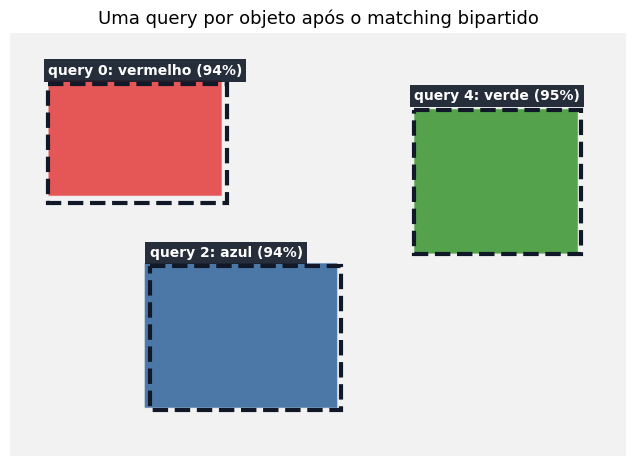

In [8]:
def caixa_normalizada_para_pixels(caixa, largura_img, altura_img):
    cx, cy, w, h = caixa
    x1 = (cx - w / 2) * largura_img
    y1 = (cy - h / 2) * altura_img
    return x1, y1, w * largura_img, h * altura_img

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(imagem)

for query, objeto in zip(queries_associadas, objetos_associados):
    classe = objetos[objeto][0]
    x, y, w, h = caixa_normalizada_para_pixels(caixas_preditas[query], largura, altura)
    ax.add_patch(Rectangle(
        (x, y), w, h,
        fill=False, linewidth=3, edgecolor="#111827", linestyle="--"
    ))
    confianca = probabilidades[query, classes_gt[objeto]]
    ax.text(
        x, max(12, y - 5), f"query {query}: {classe} ({confianca:.0%})",
        color="white", weight="bold",
        bbox=dict(facecolor="#111827", alpha=0.9, pad=3, edgecolor="none")
    )

ax.set_title("Uma query por objeto após o matching bipartido")
ax.axis("off")
plt.show()

## Takeaways

- O DETR produz um **conjunto fixo de predições**, em vez de propostas independentes seguidas de NMS.
- A codificação posicional preserva a localização espacial após o mapa de características ser convertido em sequência.
- O algoritmo húngaro encontra a associação global de menor custo entre queries e objetos reais.
- Cada objeto supervisiona exatamente uma query; as demais recebem o alvo **sem objeto**.
- A loss combina classificação, distância L1 e GIoU para equilibrar classe e localização.

Referência: [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872), Carion et al. (2020).